<a href="https://colab.research.google.com/github/harshkumar8a/banana-ripeness-detection/blob/main/banana_ripeness_detection_resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📷🍌⚙️ **Banana Ripeness Detection with ResNet18

In [ ]:
!pip install opendatasets

In [ ]:
# === 1. Imports. ===
import os
import platform
import cv2
import time
import random
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision import models
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import psutil
import subprocess
import zipfile
from IPython.display import display, Markdown
import opendatasets as op
import pathlib


In [ ]:
# === 2. Cleanup Previous Outputs. ===
for f in [
    "best_model.pth", "preprocessing_benchmark_results.csv",
    "fps_comparison_chart.pdf", "accuracy_loss_curves.pdf", "accuracy_loss_curves.png",
    "classification_report.pdf", "classification_report.png",
    "confusion_matrix_with_interpretation.pdf", "confusion_matrix_with_interpretation.png",
    "output_bundle.zip"
]:
    if os.path.exists(f):
        os.remove(f)

In [ ]:
# === 3. Reproducibility & Device. ===
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# === 4. System / Hardware Info. ===
def get_cpu_name():
    try:
        if platform.system() == "Windows":
            return platform.processor()
        elif platform.system() == "Darwin":
            return subprocess.check_output(
                ["sysctl", "-n", "machdep.cpu.brand_string"]
            ).strip().decode()
        elif platform.system() == "Linux":
            with open("/proc/cpuinfo") as f:
                for line in f:
                    if "model name" in line:
                        return line.strip().split(": ")[1]
    except Exception as e:
        return f"Unknown CPU ({e})"

print("\n🚀 \033[1mDevice Configuration\033[0m\n")
print(f"• \033[1mCUDA GPU Name:\033[0m {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
if torch.cuda.is_available():
    print(f"• \033[1mTotal GPU Memory:\033[0m {torch.cuda.get_device_properties(0).total_memory / 1e6:.2f} MB")
print(f"• \033[1mCPU Name:\033[0m {get_cpu_name()}")

mem = psutil.virtual_memory()
print("\n🧠 \033[1mCPU Memory Details\033[0m\n")
print(f"• \033[1mTotal Memory:\033[0m {mem.total / 1e9:.2f} GB")
print(f"• \033[1mAvailable Memory:\033[0m {mem.available / 1e9:.2f} GB")
print(f"• \033[1mUsed Memory:\033[0m {mem.used / 1e9:.2f} GB")
print(f"• \033[1mMemory Usage:\033[0m {mem.percent}%\n")


🚀 Device Configuration

• CUDA GPU Name: Tesla T4
• Total GPU Memory: 15637.09 MB
• CPU Name: Intel(R) Xeon(R) CPU @ 2.00GHz

🧠 CPU Memory Details

• Total Memory: 13.61 GB
• Available Memory: 11.03 GB
• Used Memory: 2.24 GB
• Memory Usage: 18.9%



In [ ]:
import opendatasets as op

op.download("https://www.kaggle.com/datasets/shahriar26s/banana-ripeness-classification-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: harshkumar1d
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shahriar26s/banana-ripeness-classification-dataset


100%|██████████| 221M/221M [00:03<00:00, 59.6MB/s]


In [ ]:
base_path = "banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset"

train_path = os.path.join(base_path, "train")
val_path   = os.path.join(base_path, "valid")
test_path  = os.path.join(base_path, "test")

Random image path: banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset/train/rotten/musa-acuminata-ripe-72588f9a-2653-11ec-9998-d8c4975e38aa_jpg.rf.e46f6d2c3433735938b1ef35b0fe006e.jpg
Image class: rotten
Image height: 416
Image width: 416


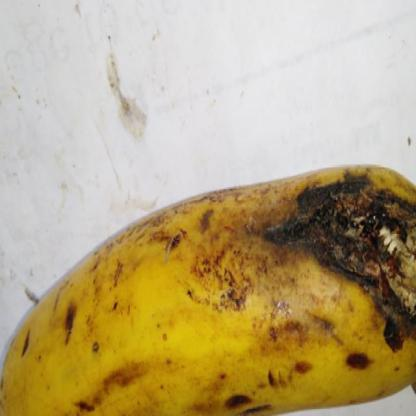

In [ ]:
import random
from PIL import Image
import pathlib # Import pathlib module

# Set seed
random.seed(42) # <- try changing this and see what happens

# Convert base_path to a Path object
base_path = pathlib.Path(base_path)

# 1. Get all image paths (* means "any combination")
# Adjusted glob pattern to match the actual directory structure
image_path_list = list(base_path.glob("*/*/*.jpg"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

In [ ]:
print('Listing contents of the downloaded dataset directory:')
!ls -R ./banana-ripeness-classification-dataset

Streaming output truncated to the last 5000 lines.
musa-acuminata-rotten-88a08b39-2653-11ec-a7b0-d8c4975e38aa_jpg.rf.4a7d4db6b88c734c674aada854789617.jpg
musa-acuminata-rotten-88a08b39-2653-11ec-a7b0-d8c4975e38aa_jpg.rf.810f6a896006be22b8a6968630ec5e0f.jpg
musa-acuminata-rotten-88a08b39-2653-11ec-a7b0-d8c4975e38aa_jpg.rf.db3777f7ddc3ca232413ed6280755c77.jpg
musa-acuminata-rotten-88ae1737-2653-11ec-a323-d8c4975e38aa_jpg.rf.2ca1c79e91b6fa48cb8e9806af20fe57.jpg
musa-acuminata-rotten-88ae1737-2653-11ec-a323-d8c4975e38aa_jpg.rf.31f6ef8a3362077fc296baceb353274e.jpg
musa-acuminata-rotten-88ae1737-2653-11ec-a323-d8c4975e38aa_jpg.rf.46e484b24e0eceb30d4c511acd96b666.jpg
musa-acuminata-rotten-88b2db88-2653-11ec-9d7d-d8c4975e38aa_jpg.rf.35fdc599051ed5f91f2c668a0803e583.jpg
musa-acuminata-rotten-88b2db88-2653-11ec-9d7d-d8c4975e38aa_jpg.rf.456287be92c4d3b4cf9f42ba1fb1d885.jpg
musa-acuminata-rotten-88b2db88-2653-11ec-9d7d-d8c4975e38aa_jpg.rf.be949158a4ec0dc191fa639322a80924.jpg
musa-acuminata-rotten-

In [ ]:
print(train_path)

/kaggle/input/banana-ripeness-classification-dataset/Banana Ripeness Classification/train


In [ ]:
class BananaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(os.listdir(root_dir))
        self.image_paths = []
        self.labels = []

        for idx, label in enumerate(self.classes):
            class_dir = os.path.join(root_dir, label)
            for img_file in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, img_file))
                self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        return image, self.labels[idx]

In [ ]:
# === 2. Transforms ===
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# === 6. Datasets ===
train_dataset = BananaDataset(train_path, transform=train_transform)
val_dataset   = BananaDataset(val_path, transform=val_test_transform)
test_dataset  = BananaDataset(test_path, transform=val_test_transform)


# === 7. DataLoaders ===
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)



In [ ]:
# === 7. Model Definition. ===
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 78.0MB/s]


In [ ]:
# === 8. Training Loop. ===
def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
            all_preds += preds.cpu().tolist()
            all_labels += labels.cpu().tolist()
    return 100. * correct / total, all_preds, all_labels

def train_model(epochs=5, patience=3):
    best_val_acc = 0.0
    best_model_state = None
    counter = 0
    train_accuracies, val_accuracies, train_losses, val_losses = [], [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
        train_acc = 100. * correct / total
        val_acc, _, _ = evaluate_model(model, val_loader)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        train_losses.append(running_loss)
        val_loss = sum(
            criterion(model(images.to(device)), labels.to(device)).item()
            for images, labels in val_loader
        )
        val_losses.append(val_loss)
        print(f"\033[1mEpoch {epoch+1}:\033[0m \033[1mLoss:\033[0m {running_loss:.2f}, \033[1mTrain Acc:\033[0m {train_acc:.2f}%, \033[1mVal Acc:\033[0m {val_acc:.2f}%")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break
    torch.save(best_model_state, "best_model.pth")
    return train_accuracies, val_accuracies, train_losses, val_losses, counter, epochs, patience

start = time.time()
train_accuracies, val_accuracies, train_losses, val_losses, counter, epochs, patience = train_model()
print(f"\n\033[1mTotal Training Time:\033[0m {round(time.time() - start)} seconds")


Epoch 1: Loss: 91.83, Train Acc: 91.43%, Val Acc: 95.19%
Epoch 2: Loss: 53.67, Train Acc: 95.08%, Val Acc: 95.99%
Epoch 3: Loss: 46.48, Train Acc: 95.65%, Val Acc: 95.64%
Epoch 4: Loss: 38.19, Train Acc: 96.66%, Val Acc: 92.70%
Epoch 5: Loss: 37.96, Train Acc: 96.42%, Val Acc: 97.51%

Total Training Time: 400 seconds


In [ ]:
# === 9. Evaluation & Reporting. ===
# Load best model for inference.
inference_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
inference_model.fc = nn.Linear(inference_model.fc.in_features, 4)
inference_model.load_state_dict(torch.load("best_model.pth"))
inference_model = inference_model.to(device)
inference_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Test set evaluation.
test_acc, test_preds, test_labels = evaluate_model(inference_model, test_loader)
print(f"\n\033[1mFinal Test Accuracy:\033[0m {test_acc:.2f}%\n")


Final Test Accuracy: 98.22%



### 

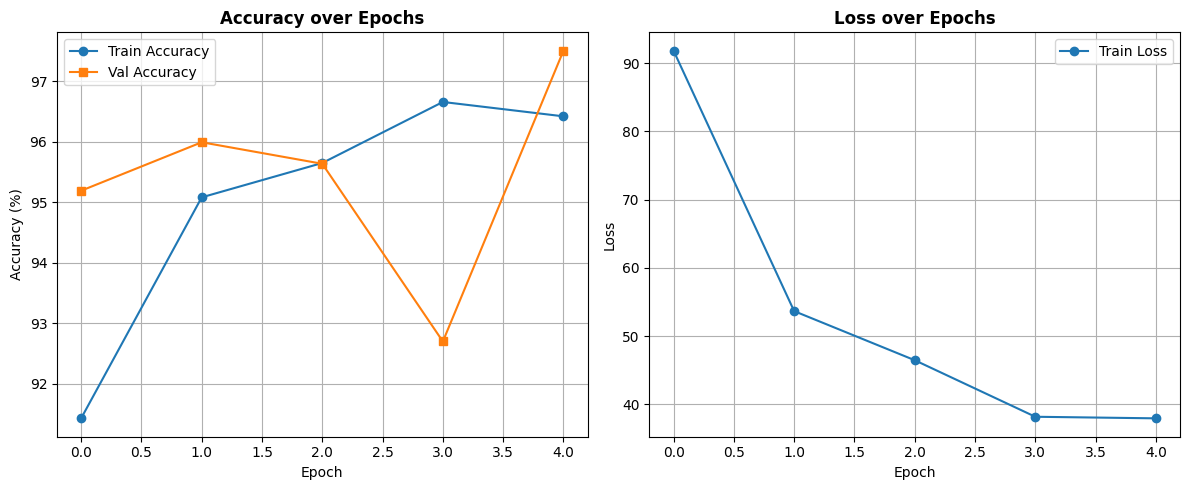

In [ ]:
# --- Accuracy / Loss curves. ---
display(Markdown("### "))  # spacing before plot.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, marker='o', label='Train Accuracy')
plt.plot(val_accuracies, marker='s', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over Epochs', fontweight='bold')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs', fontweight='bold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("accuracy_loss_curves.pdf")
plt.savefig("accuracy_loss_curves.png")
plt.show()
print()  # extra console space.

In [ ]:

# === Training Summary (Accuracy + Loss Interpretation). ===
print("\n" + "=" * 17)
print("\033[1mTraining Summary\033[0m")
print("=" * 17 + "\n")

epochs_run = len(train_accuracies)
print(f"• \033[1mTotal Epochs:\033[0m {epochs_run}")

if counter >= patience and epochs_run == epochs:
    print("• Early stopping was triggered before completing all scheduled epochs.")
else:
    print("• Training completed all scheduled epochs without triggering early stopping.")


final_train_acc = train_accuracies[-1]
final_val_acc = val_accuracies[-1]
print(f"\033[1m• Final Training Accuracy:\033[0m {final_train_acc:.2f}%")
print(f"\033[1m• Final Validation Accuracy:\033[0m {final_val_acc:.2f}%")


Training Summary

• Total Epochs: 5
• Training completed all scheduled epochs without triggering early stopping.
• Final Training Accuracy: 96.42%
• Final Validation Accuracy: 97.51%


### 

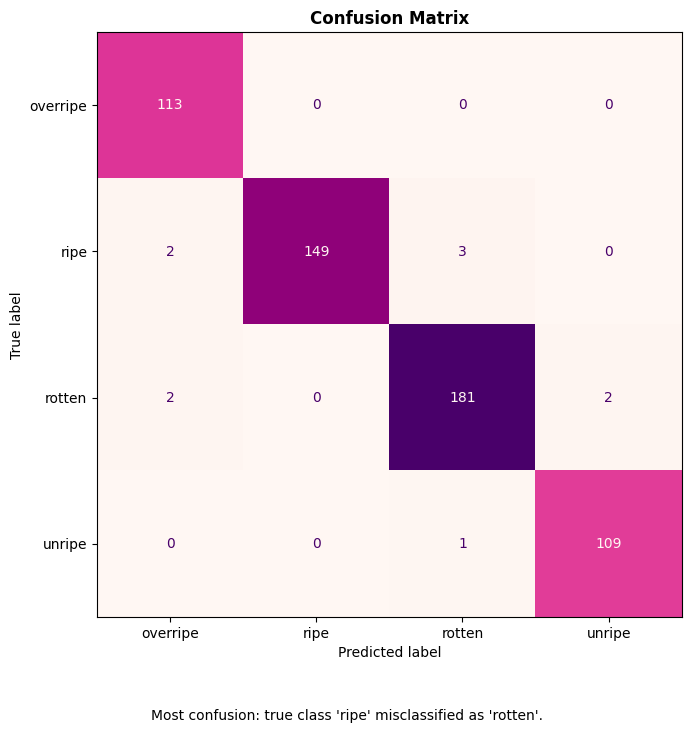


Interpretation:
Most confusion: true class 'ripe' misclassified as 'rotten'.



In [ ]:
# --- Confusion matrix with interpretation. ---
display(Markdown("### "))  # spacing before confusion matrix.
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
most_confused = np.unravel_index(np.argmax(cm * (1 - np.eye(len(cm)))), cm.shape)
true_label = test_dataset.classes[most_confused[0]]
pred_label = test_dataset.classes[most_confused[1]]
interpretation = f"Most confusion: true class '{true_label}' misclassified as '{pred_label}'.\n"

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap='RdPu', colorbar=False)
ax.set_title("Confusion Matrix", fontweight='bold')
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.grid(False)
plt.figtext(0.5, -0.05, interpretation.strip(), wrap=True, ha='center', fontsize=10, fontweight='medium')
plt.tight_layout()
plt.savefig("confusion_matrix_with_interpretation.pdf", bbox_inches='tight')
plt.savefig("confusion_matrix_with_interpretation.png", bbox_inches='tight')
plt.show()
print("\n\033[1mInterpretation:\033[0m")
print(interpretation)
